In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# <font color="#00FFFF" > 第三章 分类问题与多层感知机</font>

> 📌 **学习目标**：掌握二分类/多分类原理、理解Sigmoid和Softmax、学会使用交叉熵损失、了解MLP结构

## 📚 本章内容
1. **分类问题概述**：回归 vs 分类，二分类 vs 多分类
2. **Logistic回归**：从Odds Ratio到Sigmoid，BCE Loss(二元交叉熵损失)，PyTorch实现
3. **Softmax回归**：多分类原理，Softmax vs Hardmax，交叉熵损失
4. **Logistic vs Softmax**：统一视角与数学关系
5. **多层感知机（MLP）**：网络结构、激活函数、特征空间变换

##  <font color="#FFEA00" >第一节 分类问题概述</font>

### 回归 vs 分类

给定数据点集合 ${(x^{(i)}, t^{(i)})}$，目标是找到映射 $f: \mathbb{R}^m \rightarrow \Omega$。

| 任务类型 | 标签空间 $\Omega$ | 典型问题 |
|:---:|:---:|:---|
| **回归** | 连续值 | 房价预测、温度预测 |
| **分类** | 离散类别 | 图像分类、垃圾邮件检测 |

### 二分类 vs 多分类

| 类型 | 类别数 | 激活函数 | 损失函数 | 输出 |
|:---:|:---:|:---:|:---:|:---|
| **二分类** | K=2 | Sigmoid | BCE Loss（二元交叉熵） | 概率 p ∈ (0,1) |
| **多分类** | K>2 | Softmax | Cross-Entropy （多分类交叉熵）| 概率分布 |

💡 **关键概念**：分类模型输出的是**概率**，而非直接类别。

##  <font color="#FFEA00" >第二节 Logistic回归（二分类）</font>

### <font color="#39FF14">从线性回归到Logistic回归</font>

**线性回归的局限**：对于二分类（标签0或1），线性回归预测值可能是任意实数，无法解释为**概率**。

**解决方案**：引入Logits和Sigmoid

**Step 1: Odds Ratio（几率比）**
$$\text{odds} = \frac{p}{1-p}$$

**Step 2: Logit（对数几率）**
$$z = \text{logit}(p) = \log\left(\frac{p}{1-p}\right)$$
 p = 0.5的时候，z = 0，是分界线，将几率比等分为2    
 
**Step 3: Sigmoid函数**（Logit的反函数）
$$p = \sigma(z) = \frac{1}{1 + e^{-z}}$$
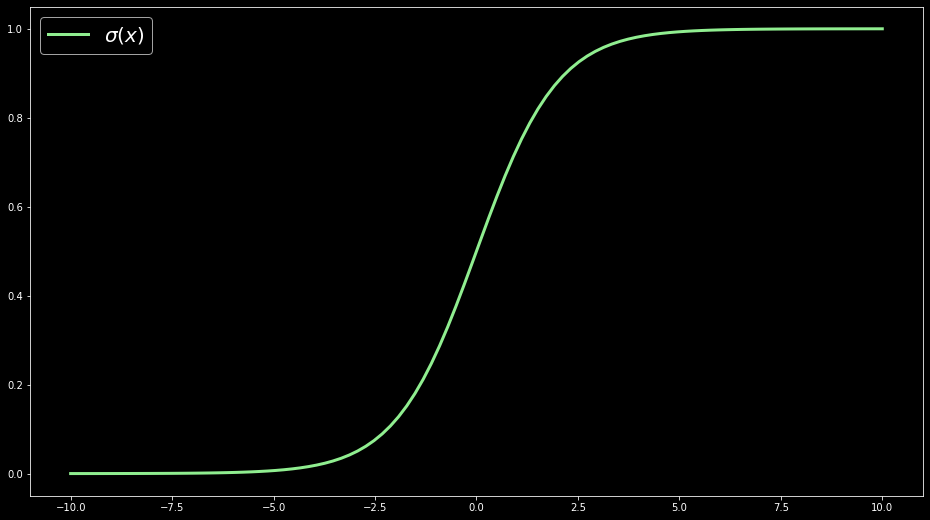

💡 **关键理解**：Logistic回归 = 线性回归 + Sigmoid
1. 计算logit：$z = w^T x + b$
2. 转换为概率：$p = \sigma(z)$

In [ ]:
# Sigmoid函数：将实数映射到(0,1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 验证：概率 -> logit -> 概率
p_test = 0.75
z_test = np.log(p_test / (1 - p_test))  # logit
p_recovered = sigmoid(z_test)

print(f"原始概率: {p_test}")
print(f"Logit: {z_test:.4f}")
print(f"Sigmoid(logit): {p_recovered:.4f}")

原始概率: 0.75
Logit: 1.0986
Sigmoid(logit): 0.7500


### <font color="#39FF14">二元交叉熵损失（BCE Loss）</font>

$$L = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]$$

**直观理解**：
- 当 $y_i = 1$：损失为 $-\log \hat{y}_i$，希望 $\hat{y}_i \rightarrow 1$
- 当 $y_i = 0$：损失为 $-\log(1-\hat{y}_i)$，希望 $\hat{y}_i \rightarrow 0$

💡 **关键洞察**：当预测接近0且错误时，损失会**指数级爆炸**。指数惩罚

**从极大似然估计（MLE）推导**：
- 假设 $y$ 服从伯努利分布：$P(y|x) = \hat{y}^y (1-\hat{y})^{1-y}$
- 对数似然：$\ell = \sum [y \log \hat{y} + (1-y)\log(1-\hat{y})]$
- 取负得损失：**BCE Loss = 负对数似然**

推导二元交叉熵是考点
为什么要取负号？

### <font color="#39FF14">PyTorch最佳实践：BCEWithLogitsLoss</font>

**数值稳定性问题**：直接 Sigmoid + BCELoss 当logits很大时会溢出。

**解决方案**：BCEWithLogitsLoss **内部合并** sigmoid和log运算。

| 组合 | 模型最后一层 | 损失函数 | 数值稳定性 | 计算效率 
|:---:|:---:|:---:|:---:|:---:|
| 方案1 | `nn.Sigmoid()` | `nn.BCELoss()` | ❌ | 低（两次运算） |
| 方案2 | 无（输出logits） | `nn.BCEWithLogitsLoss()` | ✅ | 高（一次运算） |

⚠️ **注意**：千万不要混用 `nn.Sigmoid` + `BCEWithLogitsLoss`（双重sigmoid）

In [ ]:
# PyTorch二分类完整流程

# 1. 数据准备
X, y = make_moons(n_samples=200, noise=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=13)

# 标准化（只用训练集fit，避免数据泄漏）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 转Tensor
x_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

# 2. 定义模型
model = nn.Sequential(nn.Linear(2, 1))  # 输出logits

# 3. 损失函数和优化器
loss_fn = nn.BCEWithLogitsLoss()  # 推荐！数值更稳定
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 4. 训练
for epoch in range(100):
    optimizer.zero_grad()
    output = model(x_train_tensor)
    loss = loss_fn(output, y_train_tensor)
    loss.backward()
    optimizer.step()

- 数据预处理：划分训练集和测试集要在模型训练前进行，不能在模型训练过程中动态划分。
- 只用训练集拟合scaler参数，测试集不参与拟合。
- 转化为pytorch张量。
- 创建dataloader。
- train的时候要设置model.train()，eval的时候要设置model.eval()。
- 数据划分的随机种子如果不同的话，最后运行的结果也会不同（acc loss）

##  <font color="#FFEA00" >第三节 Softmax回归（多分类）</font>

### <font color="#39FF14">Softmax函数</font>

对于 $K$ 类分类，
- 有独热分布来把每个分类类别进行无大小区别的区分
将K个logits转换为概率分布：
$$\text{softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

**性质**：
- 每个输出 $\in (0, 1)$
- 概率之和 = 1

**为什么叫Softmax？**
- **Soft**：相对于Hardmax的硬选择，提供平滑可导的概率化选择
- **Max**：指数函数放大差距，高得分类别获得更高概率

In [ ]:
# Softmax函数
def softmax(z):
    exp_z = np.exp(z - np.max(z))  # 数值稳定性
    return exp_z / np.sum(exp_z)

# 3分类示例
z = np.array([[2.0, 1.0, 0.1],
              [0.5, 2.5, 0.3]])
probs = softmax(z)
print(f"Logits: {z}")
print(f"Softmax Probabilities: {probs}")
print(f"Sum per sample: {probs.sum(axis=1)}")  # [1., 1.]

Logits: [[2.  1.  0.1]
 [0.5 2.5 0.3]]
Softmax Probabilities: [[0.27995654 0.10299025 0.04187271]
 [0.06246675 0.4615703  0.05114345]]
Sum per sample: [0.42481951 0.57518049]


#### 使用Softmax的原因
- 为什么叫softmax（软分类）
- hardmax最大的问题（取最大值的问题）是不能求导，无法用梯度下降训练神经网络
- 

### <font color="#39FF14">交叉熵损失（Cross-Entropy Loss）</font>

$$L = -\frac{1}{N} \sum_{n=1}^{N} \log h_{k^*}(x^{(n)})$$

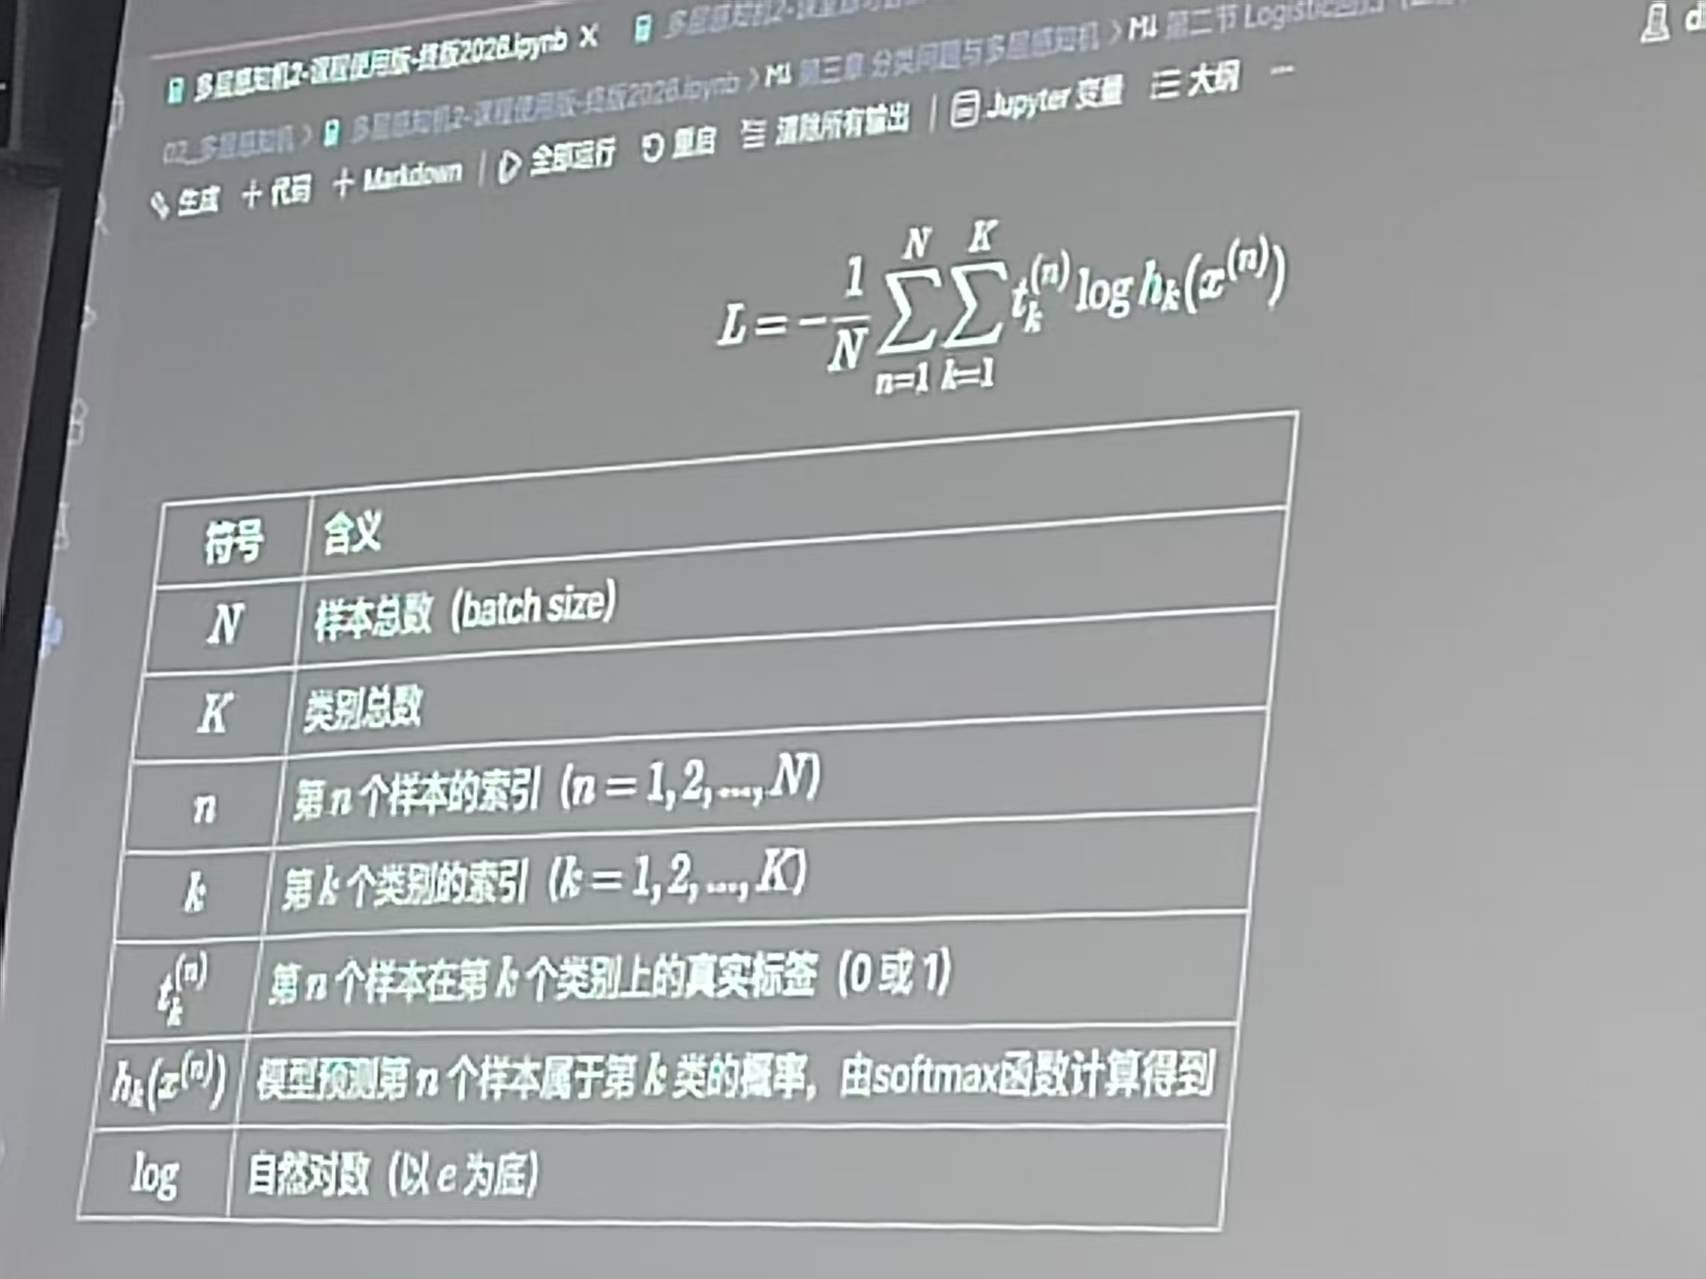
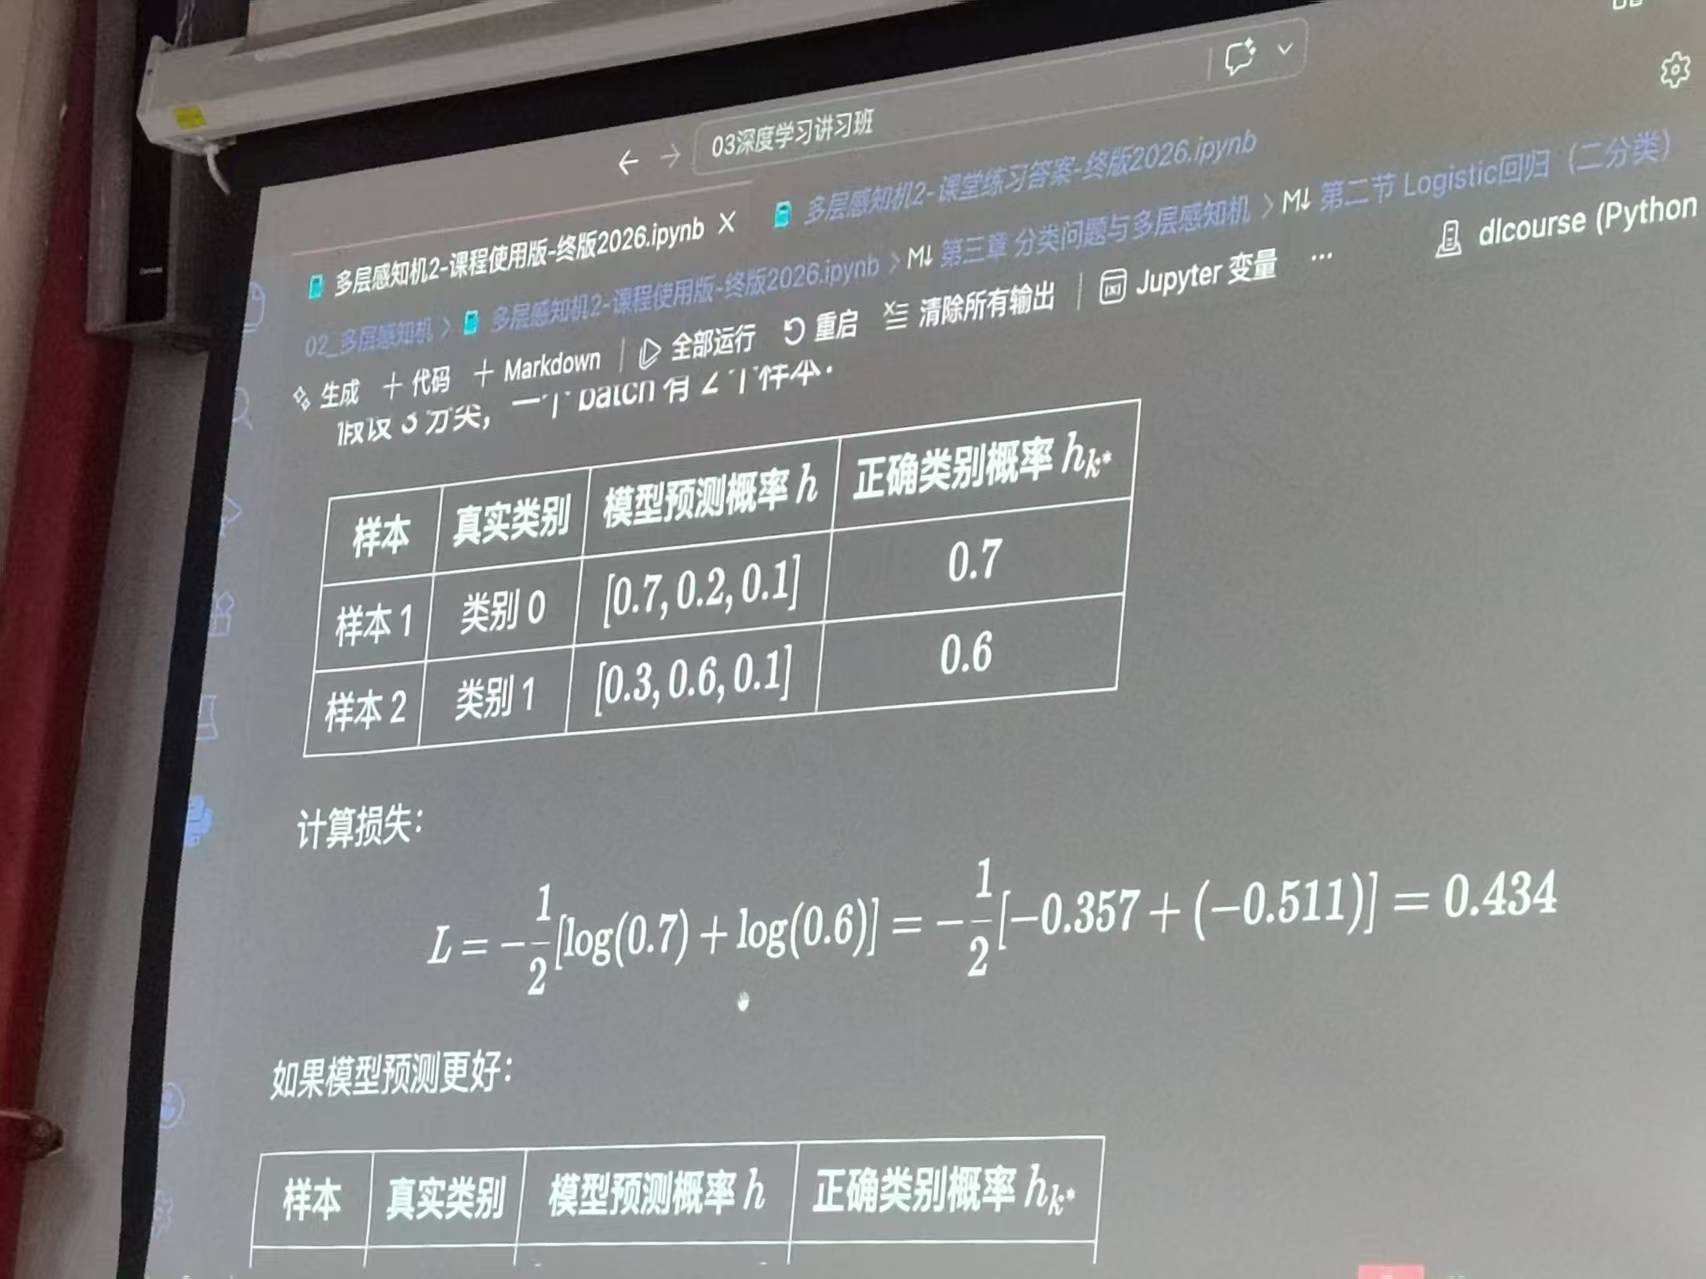
其中 $k^*$ 是样本的真实类别。

**由于独热编码的简化**：
- 原始形式：$L = -\frac{1}{N} \sum_{n} \sum_{k} t_k^{(n)} \log h_k^{(n)}$
- 简化形式：只看正确类别的概率
k = 2 的时候退化为sigmoid损失 逻辑回归
🔥 **等价关系**：最小化交叉熵 ⟺ 最大化对数似然（MLE）
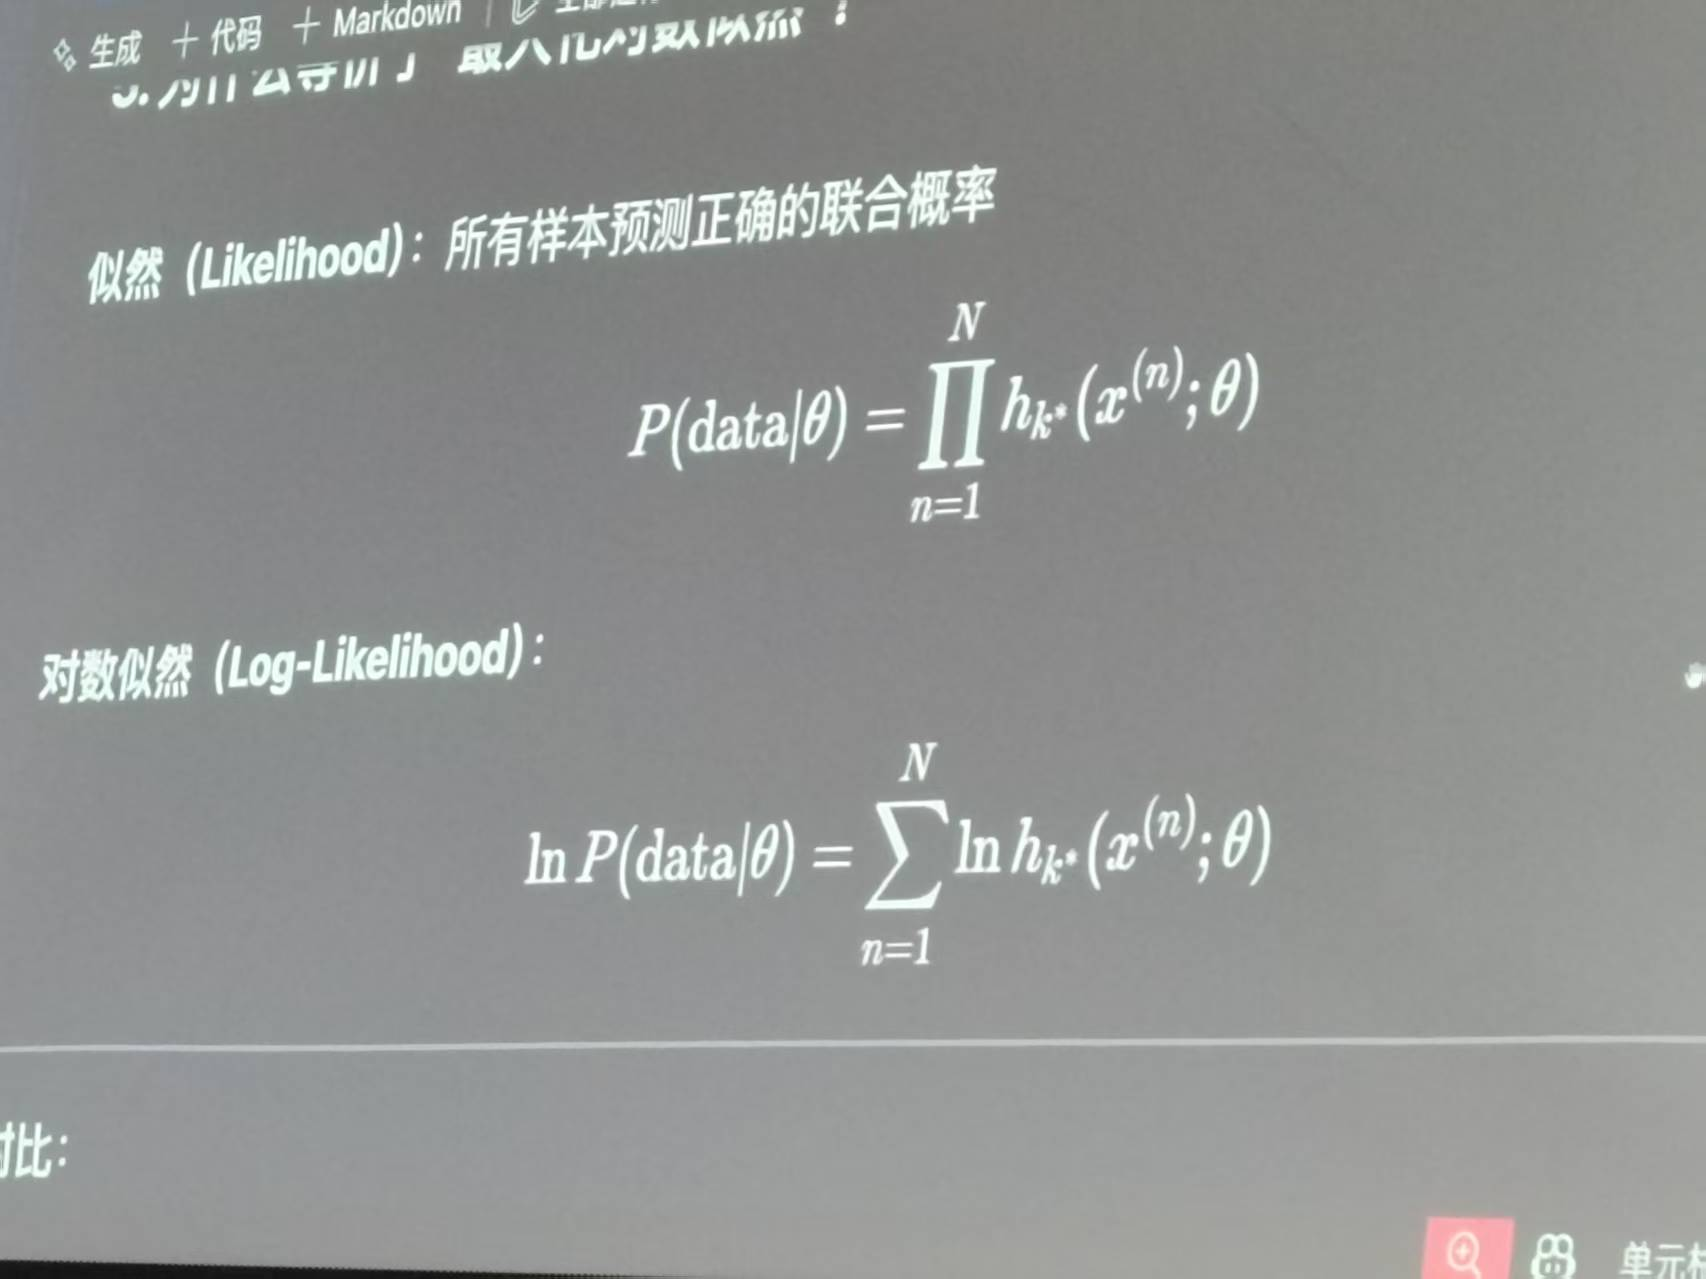
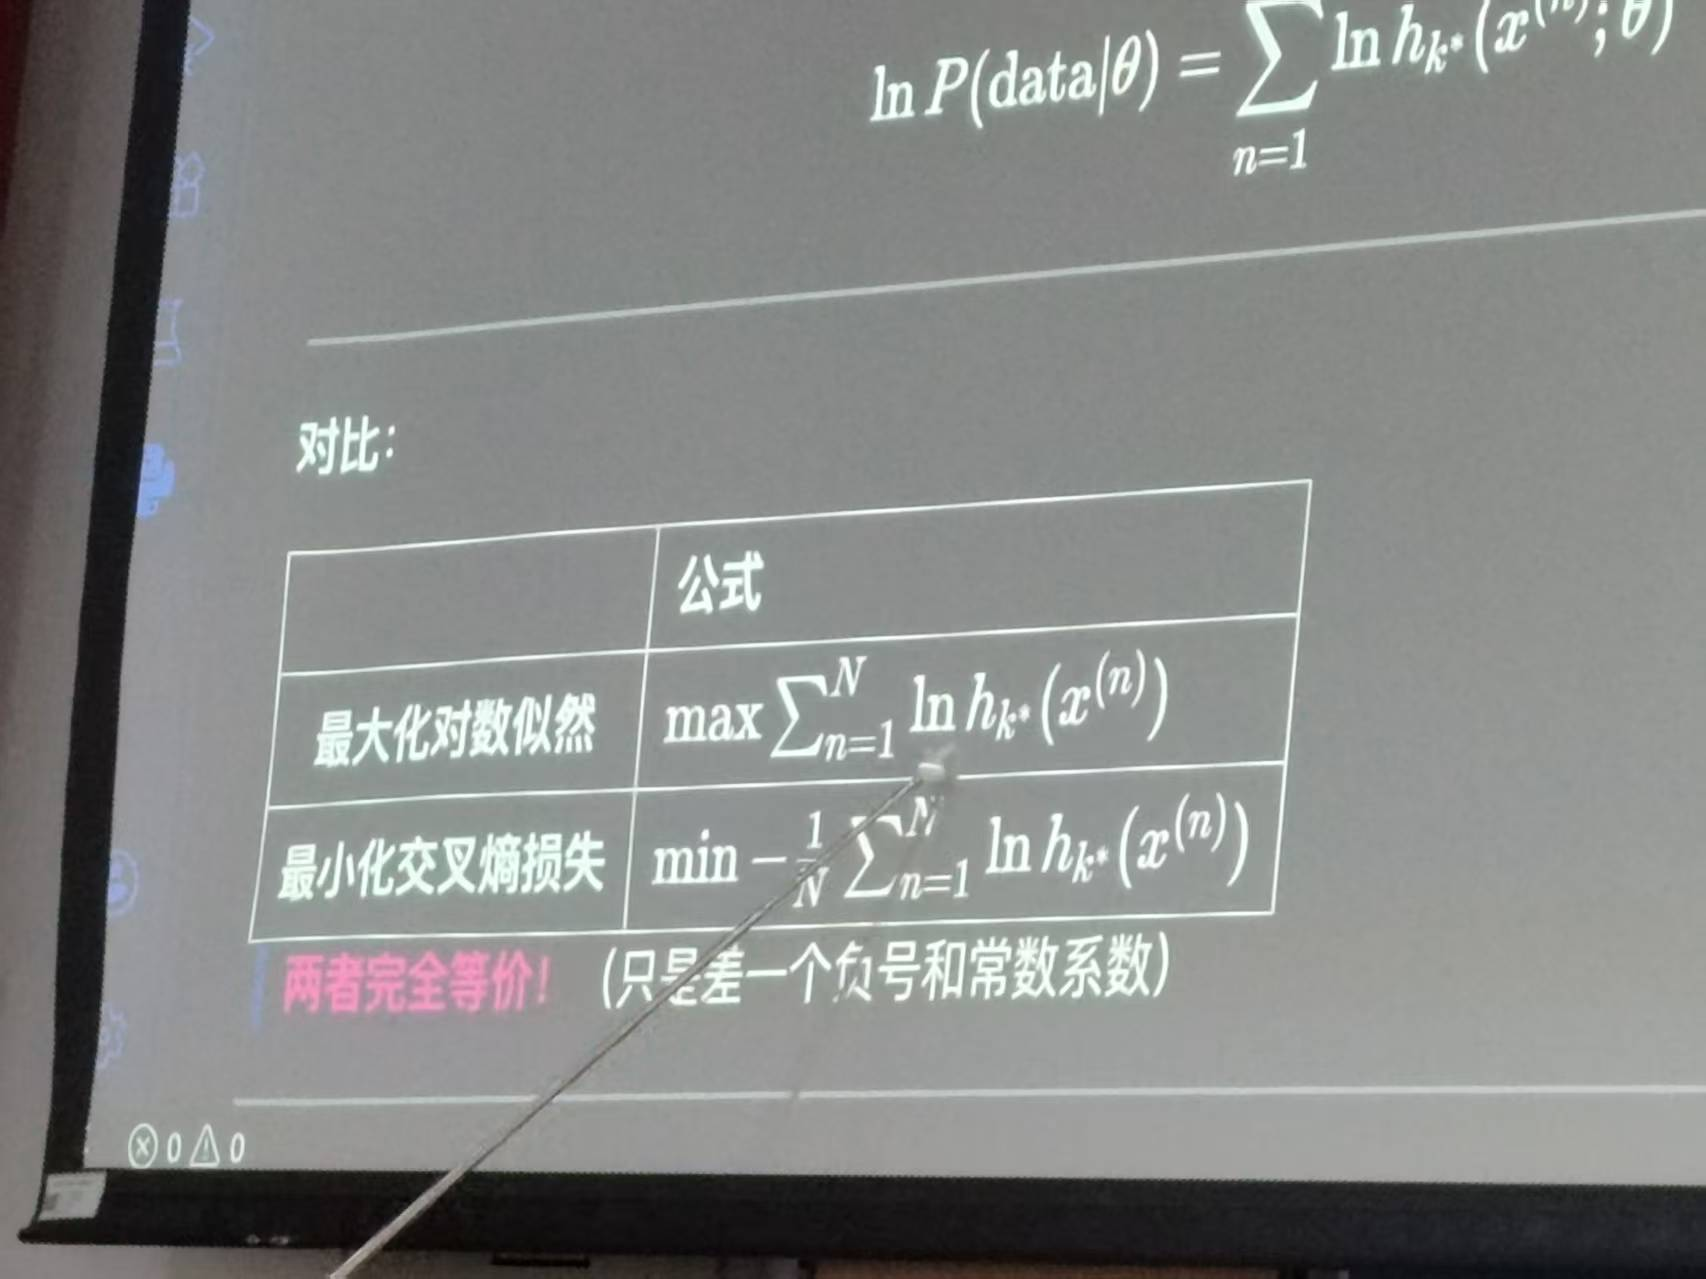
###总结部分
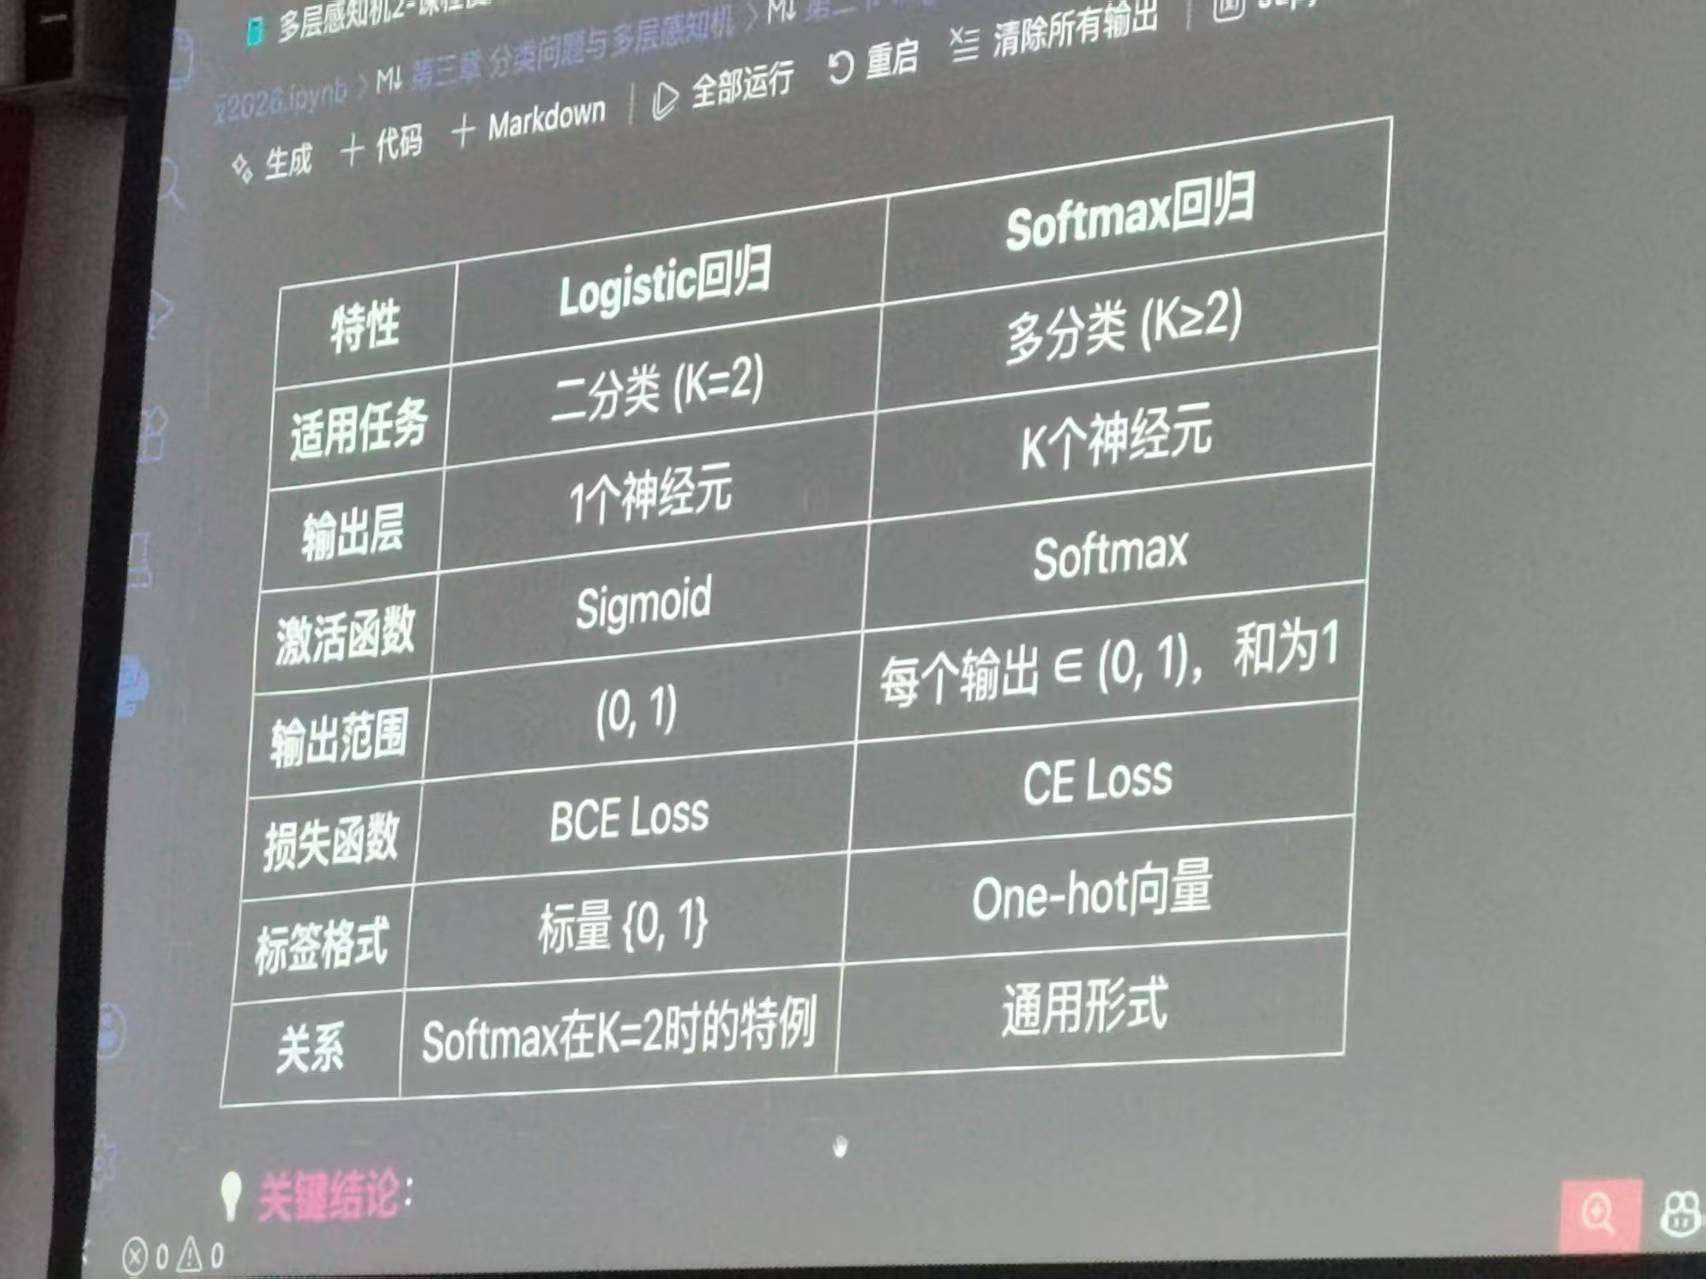

In [ ]:
# PyTorch多分类

class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    
    def forward(self, x):
        return self.linear(x)  # 输出logits

# 损失函数（内部自动softmax + 负对数似然）
criterion = nn.CrossEntropyLoss()

# 预测时获取概率
# probs = torch.softmax(outputs, dim=1)

##  <font color="#FFEA00" >第四节 Logistic vs Softmax：统一视角</font>

### <font color="#39FF14">Logistic是Softmax的特例</font>

当 $K=2$ 时，Softmax退化为Sigmoid：
$$h_1(x) = \frac{e^{z_1}}{e^{z_1} + e^{z_2}} = \frac{1}{1 + e^{-(z_1-z_2)}} = \sigma(z_1 - z_2)$$

**参数效率**：
- Logistic：学习1组权重（两类权重之差）
- Softmax：学习K组权重

### 对比总结
| 特性 | Logistic回归 | Softmax回归 |
|:---:|:---:|:---:|
| 类别数 | K=2 | K≥2 |
| 输出层 | 1个神经元 | K个神经元 |
| 激活函数 | Sigmoid | Softmax |
| 损失函数 | BCE Loss | Cross-Entropy |
| 关系 | Softmax在K=2时的特例 | 通用形式 |

##  <font color="#FFEA00" >第五节 多层感知机（MLP），也叫做全连接神经网络</font>

### <font color="#39FF14">为什么需要MLP？</font>

- Logistic回归决策边界是**线性的**
- 对于非线性可分数据（如make_moons），需要**非线性变换**
- 网格结构特点：共L层，相邻层之间的神经元两两链接（全连接），一层之间的神经元不连接

❓ **关键问题**：如果没有激活函数会怎样？

💡 **答案**：无论多少层，都等价于**单层线性模型**！
$$f(x) = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2) = Wx + b$$

**结论**：激活函数是**必需的**，用于引入非线性。

### <font color="#39FF14">常见激活函数对比</font>

| 激活函数 | 公式 | 输出范围 | 特点 |
|:---:|:---:|:---:|:---|
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | (0, 1) | 非零中心化，梯度消失 |
| **Tanh** | $\frac{e^x-e^{-x}}{e^x+e^{-x}}$ | (-1, 1) | **零中心化**，收敛更快 双曲正切 |
| **ReLU** | $\max(0, x)$ | [0, +∞) | 计算快，神经元死亡问题 |
| **Leaky ReLU** | $\max(\alpha x, x)$ | (-∞, +∞) | 解决死亡问题 |
| **GELU** | $x \cdot \Phi(x)$ | (-∞, +∞) | Transformer首选，平滑 |
| **Swish** | $x \cdot \sigma(\beta x)$ | (-∞, +∞) | 自门控机制 |

📌 **选择建议**：
- CNN/MLP：优先ReLU及其变体
- Transformer：GELU或Swish（这两个也更多的用于现在的llm）
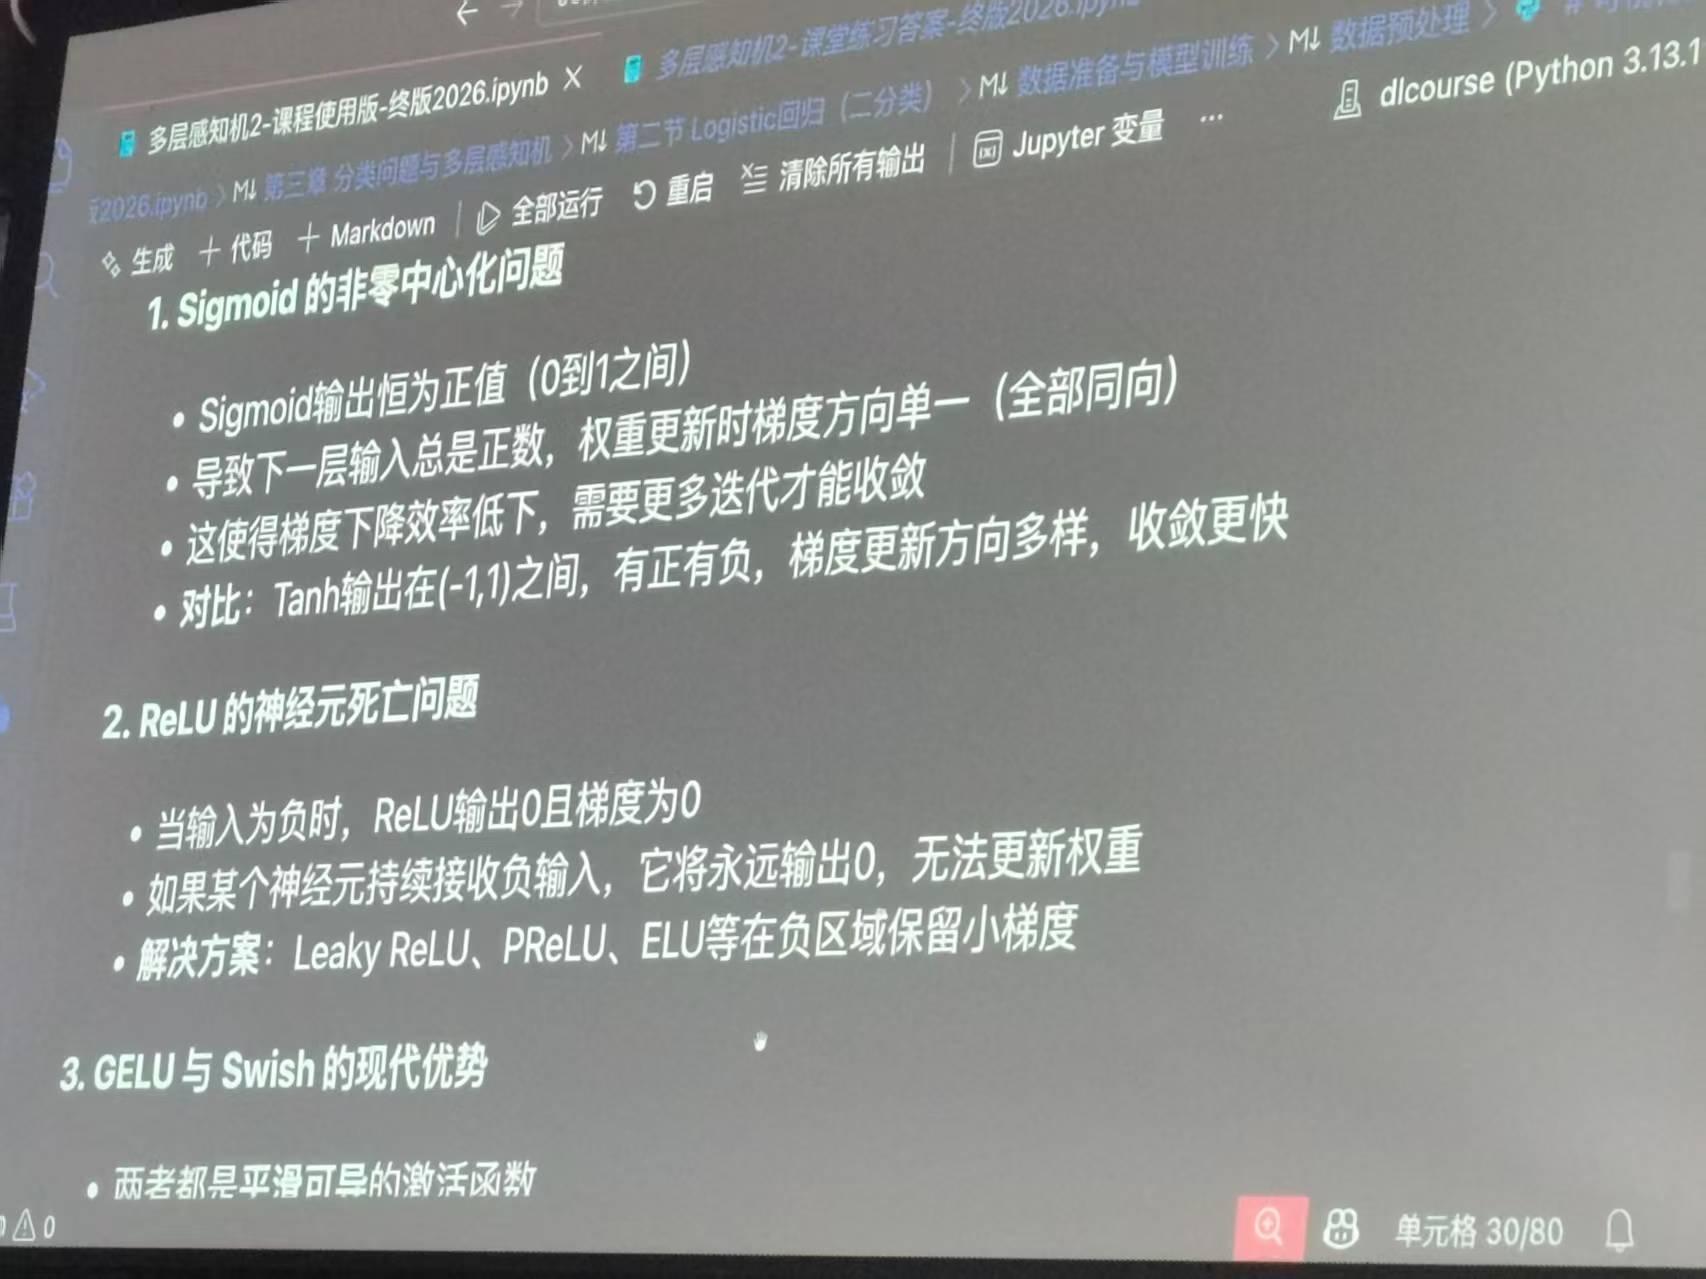
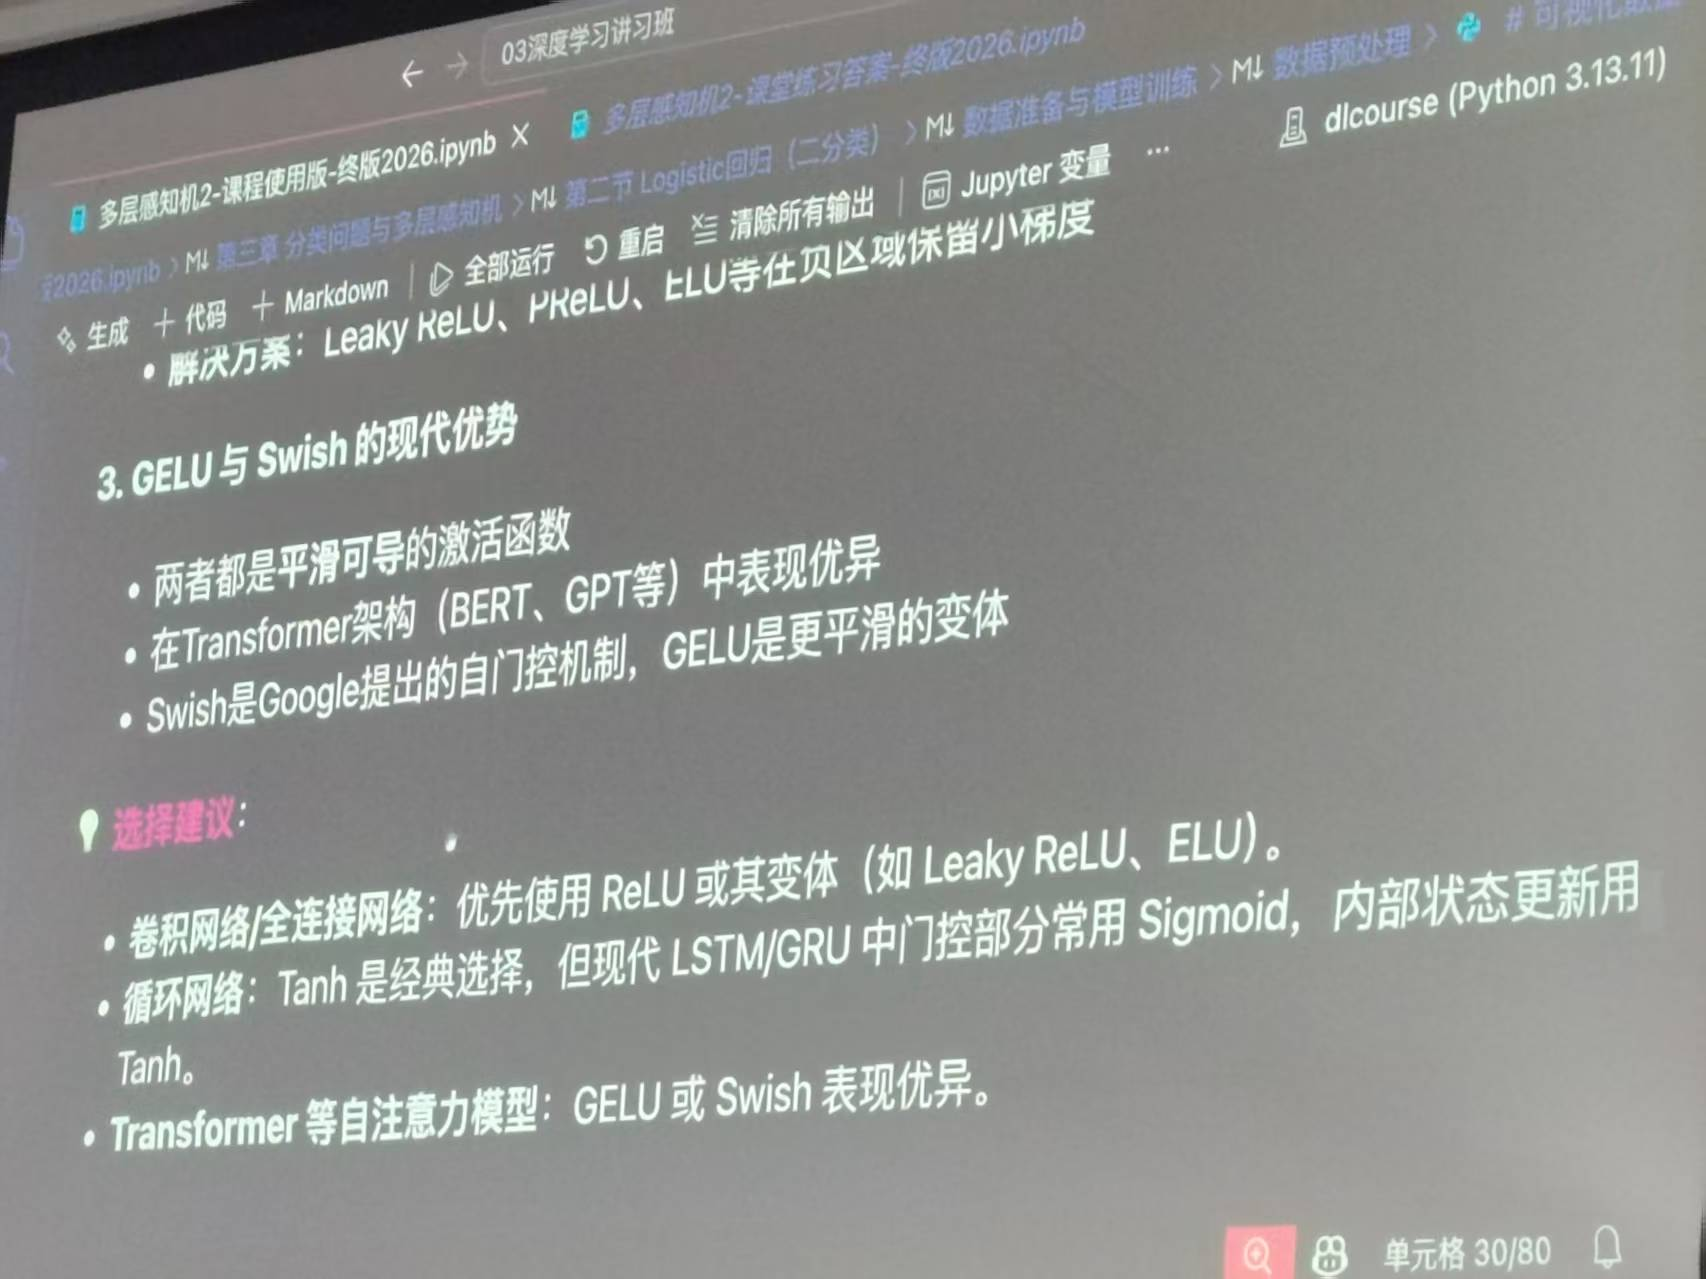

### <font color="#39FF14">激活函数的本质作用</font>

**仿射变换**（线性变换+平移）：旋转、缩放、平移特征空间
$$u_j^{(l)} = \sum_{i} w_{ji}^{(l)} y_i^{(l-1)} + b_j^{(l)}$$
神经元的操作仅限于仿射变换（线性组合+平移），不包含激活函数。

**激活函数**：对特征空间进行**非线性扭曲**
$$y_j^{(l)} = f(u_j^{(l)})$$

🎯 **核心洞察**：
> 原始特征空间中的**曲线决策边界** ↔ 激活后空间中的**直线决策边界**

> **一句话总结**：激活函数通过非线性变换扭曲特征空间，使原本线性不可分的数据在新的空间中变得线性可分！

## <font color="#FFEA00" >**本章小结**</font>

### 核心知识点

#### 一、分类问题基础
- **回归 vs 分类**：连续值 vs 离散类别
- **二分类 vs 多分类**：Sigmoid/BCE vs Softmax/CE

#### 二、Logistic回归
- **Sigmoid**：$\sigma(z) = \frac{1}{1+e^{-z}}$，将$(-\infty, +\infty)$映射到$(0,1)$
- **BCE Loss**：从MLE推导，最小化BCE = 最大化预测正确概率
- **最佳实践**：使用`BCEWithLogitsLoss`（数值更稳定）

#### 三、Softmax回归
- **Softmax**：将K个logits转换为概率分布
- **交叉熵损失**：最小化交叉熵 ⟺ 最大化对数似然

#### 四、统一视角
- **Logistic是Softmax在K=2时的特例**

#### 五、MLP
- **关键**：没有激活函数 = 单层线性模型
- **激活函数**：引入非线性，扭曲特征空间使数据可分
- **选择**：CNN/MLP用ReLU，Transformer用GELU

### 关键公式速查
| 概念 | 公式 |
|:---:|:---|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| Softmax | $\text{softmax}(z_k) = \frac{e^{z_k}}{\sum_j e^{z_j}}$ |
| BCE Loss | $L = -\frac{1}{N} \sum [y \log \hat{y} + (1-y)\log(1-\hat{y})]$ |
| Cross-Entropy | $L = -\frac{1}{N} \sum \log h_{k^*}$ |

### 实践要点
1. **数据预处理**：划分数据集是第一步，StandardScaler只用训练集fit
2. **损失函数选择**：二分类`BCEWithLogitsLoss`，多分类`CrossEntropyLoss`
3. **避免双重sigmoid**：不要用`nn.Sigmoid` + `BCEWithLogitsLoss`
4. **激活函数选择**：CNN/MLP优先ReLU，Transformer优先GELU